In [15]:
# ============================================================
# Cell 1 — Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ============================================================
# ASSUMPTIONS — RIDGE & LASSO
# ============================================================
# 1. Target: next month's annualized realized volatility.
#
# 2. Regime detection: K-means with k=2 fitted on market-level
#    features (lagged market vol, lagged market return).
#    Fitted on training data only inside each expanding window
#    step — never on future data. Same approach as Model A.
#    Regimes labeled: 0 = low vol, 1 = high vol.
#
# 3. Separate Ridge and LASSO model per regime. Each month:
#    - Fit K-means on training months
#    - Assign regimes to train AND test rows
#    - Train one Ridge and one LASSO per regime
#    - Predict for test rows assigned to that regime
#    - Fall back to naive (vol_lag1) if < 50 training rows
#
# 4. Features: 10 lagged stock-level features.
#    All features lagged >= 1 month. No future data.
#
# 5. Expanding window: minimum 60 months (5 years) initial
#    training window.
#
# 6. Capital cost: 15% normal months, 30% high vol regime months.
#    Based on real_vol_ann_lag1 (assignment rule).
#    Stock selection: 500 lowest predicted vol stocks.
# ============================================================

print('Imports and assumptions loaded.')

Imports and assumptions loaded.


In [16]:
# ============================================================
# Cell 2 — Load data
# ============================================================
df = pd.read_csv('data/clean_monthly_panel.csv', parse_dates=['date'])
df = df.sort_values(['permno', 'date']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'Unique stocks: {df["permno"].nunique()}')
print(f'Unique months: {df["date"].nunique()}')

Shape: (1912727, 21)
Columns: ['permno', 'ret', 'real_vol_monthly', 'real_vol_ann', 'real_vol_ann_lag1', 'real_vol_ann_lag2', 'real_vol_ann_lag3', 'mktcap', 'liquidity', 'mkt_vol_ann', 'mkt_vol_ann_lag1_x', 'high_vol_regime', 'n_days', 'date', 'ret_lag1', 'ret_lag3', 'ret_lag6', 'abs_ret_lag1', 'mktcap_lag1', 'momentum_12m', 'mkt_vol_ann_lag1_y']
Date range: 1990-01-31 00:00:00 to 2023-12-31 00:00:00
Unique stocks: 18074
Unique months: 408


In [17]:
# ============================================================
# Cell 3 — Basic checks
# ============================================================

# CHECK 1: Required columns
required_cols = ['permno', 'date', 'ret', 'real_vol_ann',
                 'real_vol_ann_lag1', 'real_vol_ann_lag2', 'real_vol_ann_lag3',
                 'mktcap_lag1', 'liquidity', 'momentum_12m', 'high_vol_regime',
                 'mkt_vol_ann', 'ret_lag1', 'ret_lag3', 'ret_lag6', 'abs_ret_lag1']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    print(f'WARNING: Missing columns: {missing}')
else:
    print('CHECK 1: All required columns present ✅')

# CHECK 2: Stock count per month
stock_count = df.groupby('date')['permno'].nunique()
print(f'\nCHECK 2: Stock count per month')
print(f'Min: {stock_count.min()}  Max: {stock_count.max()}  Mean: {stock_count.mean():.0f}')

# CHECK 3: Crisis months
crisis_months = df.groupby('date')['high_vol_regime'].first().sum()
print(f'\nCHECK 3: Crisis months (market vol > 30%): {crisis_months}')

CHECK 1: All required columns present ✅

CHECK 2: Stock count per month
Min: 3265  Max: 7186  Mean: 4688

CHECK 3: Crisis months (market vol > 30%): 24


In [18]:
# ============================================================
# Cell 4 — Feature engineering
# All features lagged >= 1 month. No future data anywhere.
# ============================================================
df = df.sort_values(['permno', 'date']).reset_index(drop=True)

# Market vol lagged — for K-means
df['mkt_vol_lag1'] = df.groupby('permno')['mkt_vol_ann'].shift(1)

# Market return lagged — for K-means
mkt_ret = df.groupby('date')['ret'].mean()
df['mkt_ret'] = df['date'].map(mkt_ret)
df['mkt_ret_lag1'] = df.groupby('permno')['mkt_ret'].shift(1)

# Features for Ridge/LASSO
features = [
    'real_vol_ann_lag1',
    'real_vol_ann_lag2',
    'real_vol_ann_lag3',
    'ret_lag1',
    'ret_lag3',
    'ret_lag6',
    'abs_ret_lag1',
    'mktcap_lag1',
    'momentum_12m',
    'liquidity'
]

kmeans_features = ['mkt_vol_lag1', 'mkt_ret_lag1']
target = 'real_vol_ann'

model_df = df.dropna(subset=features + [target] + kmeans_features)
model_df = model_df.sort_values(['date', 'permno']).reset_index(drop=True)

print(f'Rows before dropna: {len(df)}')
print(f'Rows after dropna:  {len(model_df)}')
print(f'Date range: {model_df["date"].min()} to {model_df["date"].max()}')
print(f'Unique stocks: {model_df["permno"].nunique()}')
print(f'Features ({len(features)}): {features}')
print(f'K-means features: {kmeans_features}')

Rows before dropna: 1912727
Rows after dropna:  1703366
Date range: 1991-01-31 00:00:00 to 2023-12-31 00:00:00
Unique stocks: 16728
Features (10): ['real_vol_ann_lag1', 'real_vol_ann_lag2', 'real_vol_ann_lag3', 'ret_lag1', 'ret_lag3', 'ret_lag6', 'abs_ret_lag1', 'mktcap_lag1', 'momentum_12m', 'liquidity']
K-means features: ['mkt_vol_lag1', 'mkt_ret_lag1']


In [19]:
# ============================================================
# Cell 5 — Expanding window setup
# ============================================================
all_months = sorted(model_df['date'].unique())
n_months = len(all_months)
min_train_months = 60  # 5 year minimum

test_months = all_months[min_train_months:]

print(f'Total months available:      {n_months}')
print(f'Minimum training window:     {min_train_months} months')
print(f'First prediction month:      {test_months[0]}')
print(f'Last prediction month:       {test_months[-1]}')
print(f'Number of prediction months: {len(test_months)}')

Total months available:      396
Minimum training window:     60 months
First prediction month:      1996-01-31 00:00:00
Last prediction month:       2023-12-31 00:00:00
Number of prediction months: 336


In [21]:
# ============================================================
# Cell 6 — Expanding window loop: K-means + Ridge + LASSO
# ============================================================

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

K = 2
MIN_REGIME_ROWS = 50
MAX_TRAIN_ROWS  = 20000

results = []

for i, test_month in enumerate(tqdm(test_months, desc='Fitting Ridge + LASSO')):

    train_mask = model_df['date'] < test_month
    test_mask  = model_df['date'] == test_month

    df_train = model_df[train_mask].copy()
    df_test  = model_df[test_mask].copy()

    if len(df_test) == 0:
        continue

    # K-means on one row per month (market level)
    mkt_train = (df_train.groupby('date')[kmeans_features]
                 .first().reset_index(drop=True))

    scaler_km = StandardScaler()
    mkt_train_sc = scaler_km.fit_transform(mkt_train)

    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    km.fit(mkt_train_sc)

    high_vol_cluster = int(np.argmax(km.cluster_centers_[:, 0]))

    df_train['regime'] = (km.predict(scaler_km.transform(
        df_train[kmeans_features].values)) == high_vol_cluster).astype(int)
    df_test['regime'] = (km.predict(scaler_km.transform(
        df_test[kmeans_features].values)) == high_vol_cluster).astype(int)

    df_test['pred_vol_ridge'] = np.nan
    df_test['pred_vol_lasso'] = np.nan
    df_test['pred_vol_naive'] = df_test['real_vol_ann_lag1'].values
    df_test['fallback_used']  = False

    for regime in [0, 1]:
        train_r = df_train[df_train['regime'] == regime]
        test_r  = df_test[df_test['regime'] == regime]

        if len(test_r) == 0:
            continue

        if len(train_r) < MIN_REGIME_ROWS:
            df_test.loc[df_test['regime'] == regime, 'pred_vol_ridge'] = \
                df_test.loc[df_test['regime'] == regime, 'real_vol_ann_lag1']
            df_test.loc[df_test['regime'] == regime, 'pred_vol_lasso'] = \
                df_test.loc[df_test['regime'] == regime, 'real_vol_ann_lag1']
            df_test.loc[df_test['regime'] == regime, 'fallback_used'] = True
            continue

        if len(train_r) > MAX_TRAIN_ROWS:
            train_r = train_r.sample(MAX_TRAIN_ROWS, random_state=42)

        X_train_r = train_r[features].values
        y_train_r = train_r[target].values
        X_test_r  = test_r[features].values

        scaler_r = StandardScaler()
        X_train_r_sc = scaler_r.fit_transform(X_train_r)
        X_test_r_sc  = scaler_r.transform(X_test_r)

        ridge = Ridge(alpha=10.0)
        ridge.fit(X_train_r_sc, y_train_r)
        df_test.loc[df_test['regime'] == regime, 'pred_vol_ridge'] = \
            ridge.predict(X_test_r_sc)

        lasso = Lasso(alpha=0.0005, max_iter=5000)
        lasso.fit(X_train_r_sc, y_train_r)
        df_test.loc[df_test['regime'] == regime, 'pred_vol_lasso'] = \
            lasso.predict(X_test_r_sc)

    results.append(df_test[['permno', 'date', target, 'real_vol_ann_lag1',
                             'ret', 'high_vol_regime', 'regime',
                             'pred_vol_ridge', 'pred_vol_lasso',
                             'pred_vol_naive', 'fallback_used']])

df_results = pd.concat(results, ignore_index=True)

print(f'\nResults shape: {df_results.shape}')
print(f'Months covered: {df_results["date"].nunique()}')
print(f'Fallback rows used: {df_results["fallback_used"].sum()}')
print(df_results.head())

Fitting Ridge + LASSO: 100%|██████████| 336/336 [03:01<00:00,  1.85it/s]



Results shape: (1404824, 11)
Months covered: 336
Fallback rows used: 0
   permno       date  real_vol_ann  real_vol_ann_lag1       ret  \
0   10001 1996-01-31      0.145538           0.117134 -0.026669   
1   10002 1996-01-31      0.080544           0.107263 -0.035713   
2   10009 1996-01-31      0.131577           0.118979 -0.009175   
3   10011 1996-01-31      0.078265           0.093773  0.085107   
4   10012 1996-01-31      0.106936           0.156292 -0.104763   

   high_vol_regime  regime  pred_vol_ridge  pred_vol_lasso  pred_vol_naive  \
0            False       1        0.106078        0.106493        0.117134   
1            False       1        0.124397        0.124424        0.107263   
2            False       1        0.120523        0.120988        0.118979   
3            False       1        0.111314        0.110857        0.093773   
4            False       1        0.140269        0.141448        0.156292   

   fallback_used  
0          False  
1          False  

In [22]:
# ============================================================
# Cell 7 — Statistical evaluation
# ============================================================

def eval_model(actual, predicted, name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2   = r2_score(actual, predicted)
    print(f'{name:25s} | RMSE: {rmse:.4f} | R2: {r2:.4f}')

print('=== Overall Performance (vol scale) ===')
eval_model(df_results[target], df_results['pred_vol_ridge'], 'Ridge (K-means)')
eval_model(df_results[target], df_results['pred_vol_lasso'], 'LASSO (K-means)')
eval_model(df_results[target], df_results['pred_vol_naive'], 'Naive baseline')
print()

print('=== Performance by Regime ===')
for regime, label in [(0, 'Low vol regime'), (1, 'High vol regime')]:
    sub = df_results[df_results['regime'] == regime]
    if len(sub) == 0:
        continue
    print(f'\n  {label} (n={len(sub)})')
    eval_model(sub[target], sub['pred_vol_ridge'], '  Ridge')
    eval_model(sub[target], sub['pred_vol_lasso'], '  LASSO')
    eval_model(sub[target], sub['pred_vol_naive'], '  Naive')

=== Overall Performance (vol scale) ===
Ridge (K-means)           | RMSE: 0.0551 | R2: 0.5029
LASSO (K-means)           | RMSE: 0.0550 | R2: 0.5041
Naive baseline            | RMSE: 0.0691 | R2: 0.2174

=== Performance by Regime ===

  Low vol regime (n=932923)
  Ridge                   | RMSE: 0.0503 | R2: 0.4744
  LASSO                   | RMSE: 0.0503 | R2: 0.4761
  Naive                   | RMSE: 0.0646 | R2: 0.1338

  High vol regime (n=471901)
  Ridge                   | RMSE: 0.0634 | R2: 0.4972
  LASSO                   | RMSE: 0.0633 | R2: 0.4979
  Naive                   | RMSE: 0.0772 | R2: 0.2546


In [23]:
# ============================================================
# Cell 8 — LASSO coefficients (feature selection)
# For interpretation — shows which features LASSO keeps
# ============================================================

# Refit on last 60 months for stable interpretation
last_date    = model_df['date'].max()
window_start = all_months[-61]
window_data  = model_df[
    (model_df['date'] >= window_start) &
    (model_df['date'] < last_date)
].copy()

scaler_int = StandardScaler()
X_int = scaler_int.fit_transform(window_data[features].values)
y_int = window_data[target].values

lasso_int = Lasso(alpha=0.0005, max_iter=5000)
lasso_int.fit(X_int, y_int)

ridge_int = Ridge(alpha=10.0)
ridge_int.fit(X_int, y_int)

coef_df = pd.DataFrame({
    'feature':    features,
    'lasso_coef': lasso_int.coef_,
    'ridge_coef': ridge_int.coef_
}).sort_values('lasso_coef', key=abs, ascending=False)

print('=== LASSO & Ridge Coefficients (last 60 months) ===')
print(coef_df.to_string(index=False))
print()
print(f'LASSO features set to zero: {(coef_df["lasso_coef"] == 0).sum()}')
print(f'LASSO features kept:        {(coef_df["lasso_coef"] != 0).sum()}')

=== LASSO & Ridge Coefficients (last 60 months) ===
          feature  lasso_coef  ridge_coef
real_vol_ann_lag1    0.024022    0.023869
real_vol_ann_lag2    0.015201    0.015460
real_vol_ann_lag3    0.013740    0.014096
     abs_ret_lag1    0.010256    0.011154
         ret_lag3   -0.008832   -0.010102
         ret_lag1   -0.006363   -0.007081
      mktcap_lag1   -0.001846   -0.002249
     momentum_12m   -0.001704   -0.002941
        liquidity    0.000393    0.000890
         ret_lag6    0.000000    0.002088

LASSO features set to zero: 1
LASSO features kept:        9


In [24]:
# ============================================================
# Cell 9 — Portfolio backtest
# Select 500 lowest predicted vol stocks per month
# Capital cost based on real_vol_ann_lag1 (assignment rule)
# ============================================================

N_STOCKS = 500

def run_backtest(df_res, pred_col, label):
    results = []
    for date, month_df in df_res.groupby('date'):
        month_df = month_df.dropna(subset=[pred_col, 'ret', 'real_vol_ann_lag1']).copy()
        if len(month_df) < N_STOCKS:
            continue
        high_vol_regime = month_df['high_vol_regime'].iloc[0]
        cost_rate = 0.30 if high_vol_regime else 0.15
        # Select 500 lowest predicted vol stocks
        selected = month_df.nsmallest(N_STOCKS, pred_col)
        # Capital cost uses real_vol_ann_lag1 (assignment rule)
        avg_net_rev = (
            0.05/12 - cost_rate * selected['real_vol_ann_lag1'] / 12
        ).mean()
        results.append({
            'date':            date,
            'avg_net_revenue': avg_net_rev,
            'high_vol_regime': high_vol_regime,
            'invested':        True
        })
    out = pd.DataFrame(results).sort_values('date').reset_index(drop=True)
    out['cumulative_net_revenue'] = (1 + out['avg_net_revenue']).cumprod()
    return out

ridge_monthly = run_backtest(df_results, 'pred_vol_ridge', 'Ridge')
lasso_monthly = run_backtest(df_results, 'pred_vol_lasso', 'LASSO')

print(f'Ridge months covered: {len(ridge_monthly)}')
print(f'LASSO months covered: {len(lasso_monthly)}')

Ridge months covered: 336
LASSO months covered: 336


In [25]:
# ============================================================
# Cell 10 — Performance summary
# ============================================================

def summary_stats(results, label):
    mean_m  = results['avg_net_revenue'].mean()
    std_m   = results['avg_net_revenue'].std()
    sharpe  = (mean_m / std_m) * np.sqrt(12)
    crisis  = results[results['high_vol_regime'] == True]['avg_net_revenue'].mean()
    normal  = results[results['high_vol_regime'] == False]['avg_net_revenue'].mean()
    best    = results.loc[results['avg_net_revenue'].idxmax()]
    worst   = results.loc[results['avg_net_revenue'].idxmin()]

    print(f'\n=======================================================')
    print(f'  {label.upper()} — SUMMARY STATISTICS')
    print(f'=======================================================')
    print(f'Months:                    {len(results)}')
    print(f'Avg monthly net revenue:   {mean_m:.4%}')
    print(f'Avg annual net revenue:    {mean_m*12:.4%}')
    print(f'Std monthly net revenue:   {std_m:.4%}')
    print(f'Sharpe ratio (annualized): {sharpe:.4f}')
    print(f'Best month:  {pd.Timestamp(best["date"]).strftime("%Y-%m")} ({best["avg_net_revenue"]:.4%})')
    print(f'Worst month: {pd.Timestamp(worst["date"]).strftime("%Y-%m")} ({worst["avg_net_revenue"]:.4%})')
    print(f'\n--- CRISIS VS NORMAL ---')
    print(f'Normal months avg: {normal:.4%}/month')
    print(f'Crisis months avg: {crisis:.4%}/month')

summary_stats(ridge_monthly, 'Ridge')
summary_stats(lasso_monthly, 'LASSO')


  RIDGE — SUMMARY STATISTICS
Months:                    336
Avg monthly net revenue:   0.3575%
Avg annual net revenue:    4.2900%
Std monthly net revenue:   0.0441%
Sharpe ratio (annualized): 28.0894
Best month:  2022-09 (0.3861%)
Worst month: 2020-04 (-0.0568%)

--- CRISIS VS NORMAL ---
Normal months avg: 0.3674%/month
Crisis months avg: 0.2293%/month

  LASSO — SUMMARY STATISTICS
Months:                    336
Avg monthly net revenue:   0.3578%
Avg annual net revenue:    4.2941%
Std monthly net revenue:   0.0440%
Sharpe ratio (annualized): 28.1864
Best month:  2022-09 (0.3865%)
Worst month: 2020-04 (-0.0546%)

--- CRISIS VS NORMAL ---
Normal months avg: 0.3677%/month
Crisis months avg: 0.2299%/month


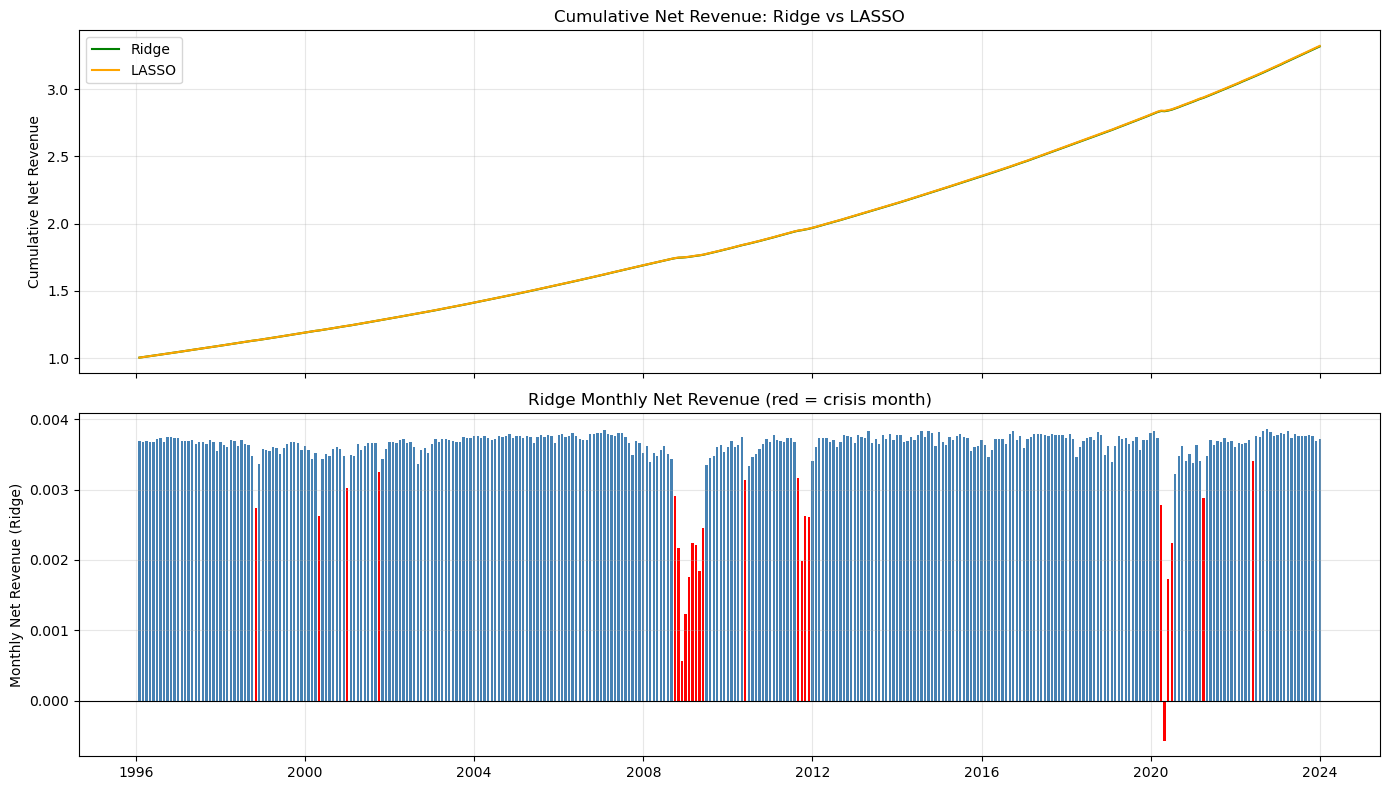

Saved to data/ridge_lasso_performance.png


In [26]:
# ============================================================
# Cell 11 — Plot cumulative net revenue
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(ridge_monthly['date'], ridge_monthly['cumulative_net_revenue'],
             label='Ridge', color='green')
axes[0].plot(lasso_monthly['date'], lasso_monthly['cumulative_net_revenue'],
             label='LASSO', color='orange')
axes[0].set_ylabel('Cumulative Net Revenue')
axes[0].set_title('Cumulative Net Revenue: Ridge vs LASSO')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Monthly net revenue
bar_colors = ['red' if x else 'steelblue' for x in ridge_monthly['high_vol_regime']]
axes[1].bar(ridge_monthly['date'], ridge_monthly['avg_net_revenue'],
            color=bar_colors, width=20)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_ylabel('Monthly Net Revenue (Ridge)')
axes[1].set_title('Ridge Monthly Net Revenue (red = crisis month)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/ridge_lasso_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/ridge_lasso_performance.png')

In [27]:
# ============================================================
# Cell 12 — Save for group comparison
# ============================================================
import importlib
import evaluation
importlib.reload(evaluation)
from evaluation import summarise_portfolio

summarise_portfolio(ridge_monthly, label='ridge_fixed')
summarise_portfolio(lasso_monthly, label='lasso_fixed')

  RIDGE_FIXED — SUMMARY STATISTICS
Months:                    336
Avg monthly net revenue:   0.3575%
Avg annual net revenue:    4.2900%
Std monthly net revenue:   0.0441%
Sharpe ratio (annualized): 28.0894
Best month:  2022-09 (0.3861%)
Worst month: 2020-04 (-0.0568%)

--- CRISIS VS NORMAL ---
Normal months (312):  avg 0.3674%/month
Crisis months ( 24):  avg 0.2293%/month

--- OOS PERIOD (2010–2023) ---
Months:                    168
Avg annual net revenue:    4.3262%
Sharpe ratio (annualized): 28.4951

Saved to data/summary_ridge_fixed.json ✅
Saved to data/monthly_results_ridge_fixed.csv ✅
  LASSO_FIXED — SUMMARY STATISTICS
Months:                    336
Avg monthly net revenue:   0.3578%
Avg annual net revenue:    4.2941%
Std monthly net revenue:   0.0440%
Sharpe ratio (annualized): 28.1864
Best month:  2022-09 (0.3865%)
Worst month: 2020-04 (-0.0546%)

--- CRISIS VS NORMAL ---
Normal months (312):  avg 0.3677%/month
Crisis months ( 24):  avg 0.2299%/month

--- OOS PERIOD (2010–2023)

{'label': 'lasso_fixed',
 'full_period_annual_net_revenue': np.float64(0.042941181971292236),
 'full_period_sharpe': np.float64(28.186403901826427),
 'full_period_worst_month': np.float64(-0.0005462934783137194),
 'full_period_best_month': np.float64(0.0038647741395138368),
 'crisis_avg_monthly': np.float64(0.0022994181753534224),
 'normal_avg_monthly': np.float64(0.00367681749675545),
 'oos_annual_net_revenue': np.float64(0.043296010041945804),
 'oos_sharpe': np.float64(28.598419011617192)}